# Chapter 2 — The learned bettor, up close

Chapter 1 gave the verdict (≈ Flat, never Kelly). This chapter shows *the agent producing it*: what its
policy looks like during training, and the multi-seed four-axis measurement that pins "≈ Flat" down with
error bars. Two pictures do most of the work — the **training orbit** and the **four-axis scoreboard**.

In [1]:
import sys; sys.path.insert(0, '.')
from blackjack_rl.analysis_loader import (
    load_bet_runs, load_bet_evals, bet_multiseed_summary, bet_provenance, near_kelly_runs,
    plot_bet_orbit, plot_kelly_distance, plot_ladder_bars, show,
)

runs = load_bet_runs()
evals = load_bet_evals()

# headline agent config per regime (growth = raw encoder; ruin = the clean cell, gamma 0.95 / double off)
AGENT_CFG = {"growth": {"bankroll_feature": "raw"}, "ruin": {"gamma": 0.95, "double": "off"}}
ruin_harmonic = runs[(runs.regime == "ruin") & (runs.lr_sched == "harmonic")]
representative = ruin_harmonic[(~ruin_harmonic.double) & (ruin_harmonic.seed == 0)].iloc[-1]

## 2.1 The training orbit — it *wanders*, it doesn't converge

Watching the greedy bet-vs-count curve over training is the most revealing view. In the heatmap, the
**low counts settle** to the minimum bet while the **high counts never settle** — flickering between a
Kelly-like ramp and flat for the whole run. (Settling to the minimum at low counts isn't skill: Kelly
*also* bets the minimum there, so it is indistinguishable from betting flat everywhere — only the high
counts, where Kelly ramps up, can reveal betting skill, and those never lock.) That perpetual high-count
flicker *is* the result, made visible.

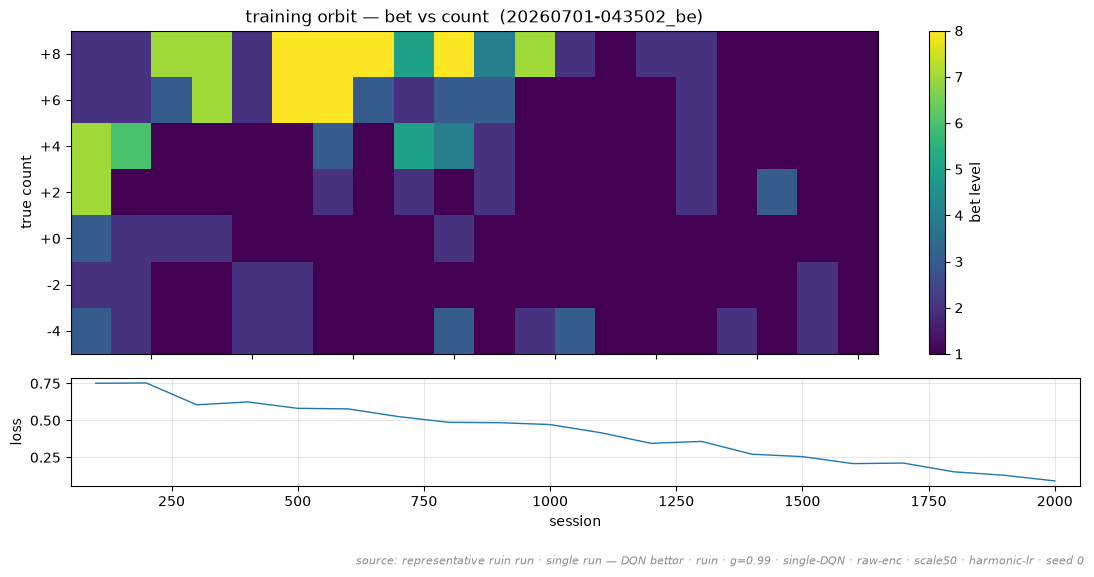

In [2]:
plot_bet_orbit(representative.path, note=bet_provenance(representative, role="representative ruin run"))

## 2.2 It *visits* Kelly — and doesn't keep it

The wandering isn't noise around flat: the orbit repeatedly *passes through* near-Kelly ramps and leaves.
The L1 distance of the bet curve to the Kelly ladder over training makes the dips explicit — each dip is a
checkpoint where the policy was briefly Kelly-shaped. So the network *can* express the ramp; it can't hold
it. (Chapter 3 shows those visited ramps, once measured, are *worse* than Flat.)

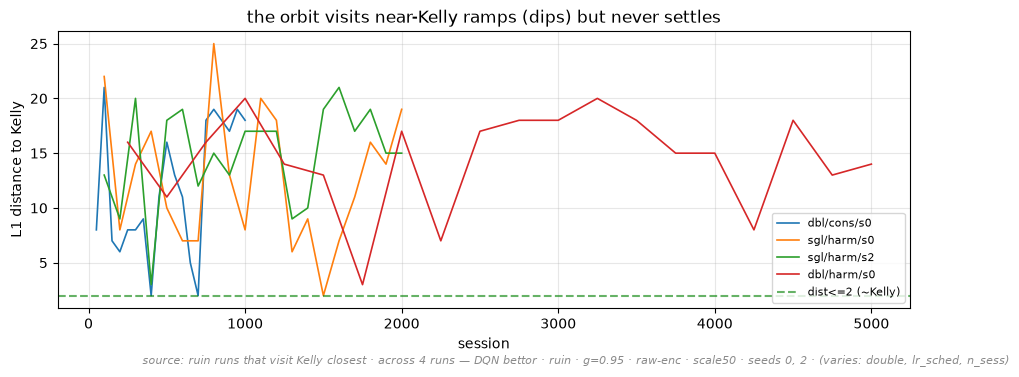

In [3]:
near_kelly = near_kelly_runs("ruin", 4)   # the runs whose orbit dips CLOSEST to Kelly (dist 2-3)
plot_kelly_distance(near_kelly, label=lambda r: f"{'dbl' if r.double else 'sgl'}/{r.lr_sched[:4]}/s{r.seed}",
                    note=bet_provenance(near_kelly, role="ruin runs that visit Kelly closest"))

## 2.3 The four-axis result — ≈ Flat, with error bars

Every trained agent, scored against Kelly and Flat on identical terms across seeds. The two axes shown as
bars carry the verdict — **growth rate** (the objective) and **deep-drawdown %** (risk); the full
four-axis numbers (incl. ruin %) are in the table below. The agent bar sits at Flat's height on growth and
never approaches Kelly; its drawdown is low (the final policy is timid) — what *restraint without sizing* looks
like. (Restraint is a real behaviour here — the undertrained and best-checkpoint policies genuinely
over-bet — but its end state is indistinguishable from Flat: a mistake avoided, not a skill gained.)

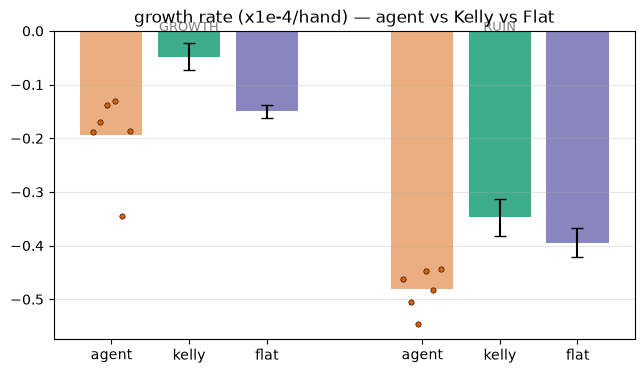

In [4]:
plot_ladder_bars(evals, "growth_1e4", AGENT_CFG, title="growth rate (x1e-4/hand) — agent vs Kelly vs Flat")

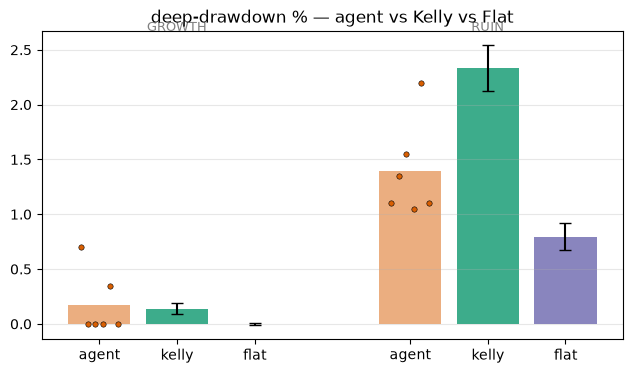

In [5]:
plot_ladder_bars(evals, "dd_pct", AGENT_CFG, title="deep-drawdown % — agent vs Kelly vs Flat")

## 2.4 The numbers behind the bars

The full multi-seed table — every hardening cell (double on/off, the ruin-γ sweep) plus the growth agent,
for both the **final** policy and the **best-checkpoint** ("the best ramp each run visited"; Chapter 3).
All three scalar axes are here: **growth**, **ruin %**, **deep-drawdown %**. Read the *final* rows for the
deployed policy; the `dd_sd` column on `double=on` previews the instability Chapter 5 flags.

In [6]:
summary = bet_multiseed_summary(evals)
agents = evals[(evals.bettor == "agent") & (evals.regime == evals.train_regime)]
show(summary, num=("growth", "growth_sd", "ruin", "dd", "dd_sd"),
     caption="Multi-seed four-axis summary (native cell) — growth x1e-4, ruin %, dd %",
     source=bet_provenance(agents, role="native-cell agents, per-config means (see n)"))

train_regime,gamma,double,bankroll_feature,phase,n,growth,growth_sd,ruin,dd,dd_sd
growth,0.000000,off,logratio,final,6,-0.28,0.16,0.00,0.13,0.30
growth,0.000000,off,none,final,6,-0.19,0.04,0.00,0.37,0.74
growth,0.000000,off,raw,best-ckpt,6,-0.56,0.21,0.32,5.58,3.76
growth,0.000000,off,raw,final,6,-0.19,0.08,0.00,0.18,0.29
growth,0.000000,on,raw,best-ckpt,1,-0.19,nan,0.05,0.65,nan
ruin,0.900000,off,raw,best-ckpt,3,-1.17,0.58,2.60,17.65,8.42
ruin,0.900000,off,raw,final,3,-0.79,0.56,2.47,9.83,14.28
ruin,0.950000,off,raw,best-ckpt,6,-1.08,0.88,2.09,13.92,12.66
ruin,0.950000,off,raw,final,6,-0.48,0.04,0.03,1.39,0.44
ruin,0.950000,on,raw,best-ckpt,6,-1.48,1.21,4.94,18.29,12.17
